## 1. 환경 설정 및 라이브러리 임포트

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import os
import numpy as np
import random
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. 데이터 확보 및 병렬 데이터 정제

In [2]:
# 데이터 다운로드 (Colab/Linux 기준)
if not os.path.exists('korean-english-park.train.tar.gz'):
    print("Downloading dataset...")
    os.system('wget https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz')
    os.system('tar -xzvf korean-english-park.train.tar.gz')

# 데이터 로드
with open('korean-english-park.train.ko', 'r', encoding='utf-8') as f:
    ko_raw = [line.strip() for line in f]
with open('korean-english-park.train.en', 'r', encoding='utf-8') as f:
    en_raw = [line.strip() for line in f]

# Step 1: 중복 제거 (Pandas 활용)
df = pd.DataFrame({'ko': ko_raw, 'en': en_raw})
print(f"Original Data: {len(df)}")

df.drop_duplicates(inplace=True)
print(f"After Duplicate Removal: {len(df)}")

# 정제된 데이터를 리스트로 변환
cleaned_corpus = df.values.tolist()

Original Data: 94123
After Duplicate Removal: 78941


## 3. 한글 맞춤형 전처리 함수 재정의

In [3]:
def preprocessing(sentence, is_english=False):
    sentence = sentence.lower().strip()
    
    # 1. 구두점 분리
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    if is_english:
        # 영어: 영문자와 특수문자만 남김
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
        # 2. 토큰 추가 및 split()
        sentence = f"<start> {sentence} <end>"
    else:
        # 한글: 한글과 특수문자만 남김
        sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)
    
    return sentence.strip()

# 데이터 필터링: 토큰 길이 40 이하인 데이터만 선별
kor_corpus, eng_corpus = [], []

for ko, en in cleaned_corpus:
    ko_pre = preprocessing(ko)
    en_pre = preprocessing(en, is_english=True)
    
    # 공백 기반 토큰화 (Mecab 미사용)
    ko_tokens = ko_pre.split()
    en_tokens = en_pre.split()
    
    if 1 <= len(ko_tokens) <= 40 and 1 <= len(en_tokens) <= 40:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

print(f"Length Filtered Data: {len(kor_corpus)}")

Length Filtered Data: 70155


## 4. 토큰화 및 텐서 변환

In [4]:
def tokenize(corpus, vocab_size=12000):
    # 특수 토큰 인덱스 정의
    word_to_index = {"<pad>": 0, "<unk>": 1, "<start>": 2, "<end>": 3}
    
    # 빈도수 기반 단어장 구축
    all_words = [word for tokens in corpus for word in tokens]
    from collections import Counter
    counts = Counter(all_words)
    
    # vocab_size에 맞춰 빈도 높은 단어 추가
    most_common = counts.most_common(vocab_size - len(word_to_index))
    for word, _ in most_common:
        word_to_index[word] = len(word_to_index)
        
    index_to_word = {v: k for k, v in word_to_index.items()}
    
    # 텐서 변환
    tensor = []
    for tokens in corpus:
        tensor.append([word_to_index.get(w, 1) for w in tokens]) # 모르는 단어는 <unk>
        
    # 패딩 처리 (Post-padding)
    max_len = max(len(t) for t in tensor)
    tensor = [t + [0] * (max_len - len(t)) for t in tensor]
    
    return torch.LongTensor(tensor), word_to_index, index_to_word

# 텐서 생성 및 각각의 Tokenizer(Index Dictionary) 확보
kor_tensor, kor_w2i, kor_i2w = tokenize(kor_corpus)
eng_tensor, eng_w2i, eng_i2w = tokenize(eng_corpus)

print(f"Kor Vocab Size: {len(kor_w2i)}")
print(f"Eng Vocab Size: {len(eng_w2i)}")

Kor Vocab Size: 12000
Eng Vocab Size: 11998


## 5. 데이터 로더 준비

In [5]:
class TranslationDataset(Dataset):
    def __init__(self, src, tgt):
        self.src = src
        self.tgt = tgt
    def __len__(self):
        return len(self.src)
    def __getitem__(self, i):
        return self.src[i], self.tgt[i]

train_loader = DataLoader(
    TranslationDataset(kor_tensor, eng_tensor), 
    batch_size=64, 
    shuffle=True
)
print("✅ 데이터 로더 구축 완료")

✅ 데이터 로더 구축 완료


## Step 4. 모델 설계 - Attention 기반 Seq2seq

In [6]:
# 1. 인코더 (Encoder)
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, x):
        # x: [batch, seq_len]
        embedded = self.embedding(x)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden # outputs: [batch, seq, hid], hidden: [1, batch, hid]

# 2. 바다나우 어텐션 (Bahdanau Attention)
class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W1 = nn.Linear(hid_dim, hid_dim)
        self.W2 = nn.Linear(hid_dim, hid_dim)
        self.V = nn.Linear(hid_dim, 1)

    def forward(self, hidden, enc_outputs):
        # hidden: [1, batch, hid] -> [batch, 1, hid]
        hidden_with_time_axis = hidden.transpose(0, 1)
        
        # Score 계산: V * tanh(W1(enc) + W2(hid))
        score = self.V(torch.tanh(self.W1(enc_outputs) + self.W2(hidden_with_time_axis)))
        
        # Attention Weights: Softmax를 통해 가중치 합이 1이 되도록 함
        attn_weights = F.softmax(score, dim=1)
        
        # Context Vector: 가중치와 인코더 출력의 가중합
        context_vector = torch.sum(attn_weights * enc_outputs, dim=1)
        return context_vector, attn_weights

# 3. 디코더 (Decoder)
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.attention = BahdanauAttention(hid_dim)
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, x, hidden, enc_outputs):
        # x: [batch] (현재 시점의 단어 인덱스)
        context_vector, attn_weights = self.attention(hidden, enc_outputs)
        
        # 입력을 임베딩하고 컨텍스트 벡터와 결합
        x = self.embedding(x).unsqueeze(1) # [batch, 1, emb]
        concat = torch.cat([context_vector.unsqueeze(1), x], dim=-1)
        
        # GRU 통과 및 최종 예측
        output, hidden = self.gru(concat, hidden)
        prediction = self.fc(output.squeeze(1))
        
        return prediction, hidden, attn_weights

In [15]:
# 번역 추론 및 평가 함수
def evaluate(sentence, encoder, decoder):
    encoder.eval(); decoder.eval()
    sentence = preprocessing(sentence).split()
    inputs = [kor_w2i.get(w, 1) for w in sentence]
    inputs = torch.LongTensor(inputs).unsqueeze(0).to(device)
    
    res, attns = [], []
    with torch.no_grad():
        enc_out, hid = encoder(inputs)
        dec_in = torch.tensor([eng_w2i['<start>']]).to(device)
        
        for _ in range(40):
            out, hid, weight = decoder(dec_in, hid, enc_out)
            attns.append(weight.squeeze().cpu().numpy())
            pred = out.argmax(1).item()
            
            # 1. <end> 토큰(3)이 나오면 루프 즉시 종료
            if pred == 3: 
                break
            
            # 2. 특수 토큰(0, 1, 2)이 아닐 때만 결과 리스트에 단어 추가
            if pred not in [0, 1, 2]:
                # 단어장에 인덱스가 없을 경우를 대비해 get() 사용
                word = eng_i2w.get(pred, "<unk>")
                res.append(word)
            
            dec_in = torch.tensor([pred]).to(device)
            
    return res, sentence, np.array(attns)

## Step 5. 훈련 및 번역

In [16]:
import torch.nn.init as init

# 1. 가중치 초기화 함수 정의 (Xavier 초기화)
def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            init.xavier_uniform_(param.data)
        elif 'bias' in name:
            init.constant_(param.data, 0)

# 2. 모델 재생성 및 초기화 적용
encoder = Encoder(len(kor_w2i), 256, 512).to(device)
decoder = Decoder(len(eng_w2i), 256, 512).to(device)
encoder.apply(init_weights)
decoder.apply(init_weights)

# 3. 학습률 하향 조정 (0.0005 -> 0.0001)
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.0001)
# 강한 클리핑을 위해 0.1~0.5 권장
clip_value = 0.5 

for epoch in range(10):
    encoder.train()
    decoder.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for src, tgt in pbar: # 여기서부터 루프 시작
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        
        enc_out, hid = encoder(src)
        
        loss = 0
        dec_in = tgt[:, 0]
        
        for t in range(1, tgt.size(1)):
            out, hid, _ = decoder(dec_in, hid, enc_out)
            
            # [수정] 수치 안정성 체크: out에 NaN이 있으면 루프 중단
            if torch.isnan(out).any():
                loss = None
                break
                
            loss += criterion(out, tgt[:, t])
            dec_in = tgt[:, t] if random.random() < 0.8 else out.argmax(1)
        
        # [수정] loss가 NaN이거나 계산에 문제가 생겼을 때의 처리
        if loss is None or torch.isnan(loss):
            optimizer.zero_grad()
            continue # <--- 이제 루프 안에 정확히 위치하므로 에러가 나지 않습니다.
            
        loss.backward()
        
        # [수정] 기울기 클리핑 강화 (NaN 방지 핵심)
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), clip_value)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), clip_value)
        
        optimizer.step()
        
        batch_loss = loss.item() / tgt.size(1)
        total_loss += batch_loss
        pbar.set_postfix(avg_loss=total_loss / (pbar.n + 1))
    # 여기까지가 pbar 루프 끝

    # 에폭 종료 후 테스트 번역
    res, _, _ = evaluate("오바마는 대통령이다.", encoder, decoder)
    print(f"\n[Epoch {epoch+1}] Result: {' '.join(res)}")

Epoch 1: 100%|██████████| 1097/1097 [02:22<00:00,  7.71it/s, avg_loss=4.01]



[Epoch 1] Result: the assisting


Epoch 2: 100%|██████████| 1097/1097 [02:22<00:00,  7.69it/s, avg_loss=3.73]



[Epoch 2] Result: the been been emphasize


Epoch 3: 100%|██████████| 1097/1097 [02:22<00:00,  7.71it/s, avg_loss=3.61]


...


[Epoch 8] Result: according to be a statement . , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,


Epoch 9: 100%|██████████| 1097/1097 [02:22<00:00,  7.72it/s, avg_loss=3.3] 



[Epoch 9] Result: according to be to the . , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,


Epoch 10: 100%|██████████| 1097/1097 [02:19<00:00,  7.88it/s, avg_loss=3.15]


[Epoch 10] Result: according to be to the . , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,


In [10]:
kor_corpus, eng_corpus = [], []

for ko, en in cleaned_corpus:
    ko_pre = preprocessing(ko)
    en_pre = preprocessing(en, is_english=True)
    
    ko_tokens = ko_pre.split()
    en_tokens = en_pre.split()
    
    # [수정] 최소 길이 2단어 이상, 최대 40단어 이하로 엄격히 제한
    if 2 <= len(ko_tokens) <= 40 and 2 <= len(en_tokens) <= 40:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

print(f"필터링 후 데이터: {len(kor_corpus)} 쌍")

필터링 후 데이터: 69631 쌍


In [11]:
# 훈련 코드 내 loss 계산 부분 수정
for t in range(1, tgt.size(1)):
    out, hid, _ = decoder(dec_in, hid, enc_out)
    
    # 1. 텐서에 NaN이 있는지 체크
    if torch.isnan(out).any():
        continue
        
    current_loss = criterion(out, tgt[:, t])
    loss += current_loss
    dec_in = tgt[:, t] if random.random() < 0.8 else out.argmax(1)

# 2. 최종 loss가 NaN이면 해당 배치는 업데이트 건너뜀
if torch.isnan(loss) or loss.item() == 0:
    optimizer.zero_grad()
    continue

loss.backward()
# 클리핑을 0.1로 아주 강하게 조입니다.
torch.nn.utils.clip_grad_norm_(encoder.parameters(), 0.1)
torch.nn.utils.clip_grad_norm_(decoder.parameters(), 0.1)
optimizer.step()

SyntaxError: 'continue' not properly in loop (970102406.py, line 16)

In [18]:
epochs = 20 # 추가로 20번 더 학습 (총 30회)

for epoch in range(epochs):
    encoder.train()
    decoder.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for src, tgt in pbar: # 여기서부터 루프 시작
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        
        enc_out, hid = encoder(src)
        
        loss = 0
        dec_in = tgt[:, 0]
        
        for t in range(1, tgt.size(1)):
            out, hid, _ = decoder(dec_in, hid, enc_out)
            
            # [수정] 수치 안정성 체크: out에 NaN이 있으면 루프 중단
            if torch.isnan(out).any():
                loss = None
                break
                
            loss += criterion(out, tgt[:, t])
            dec_in = tgt[:, t] if random.random() < 0.8 else out.argmax(1)
        
        # [수정] loss가 NaN이거나 계산에 문제가 생겼을 때의 처리
        if loss is None or torch.isnan(loss):
            optimizer.zero_grad()
            continue # <--- 이제 루프 안에 정확히 위치하므로 에러가 나지 않습니다.
            
        loss.backward()
        
        # [수정] 기울기 클리핑 강화 (NaN 방지 핵심)
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), clip_value)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), clip_value)
        
        optimizer.step()
        
        batch_loss = loss.item() / tgt.size(1)
        total_loss += batch_loss
        pbar.set_postfix(avg_loss=total_loss / (pbar.n + 1))
    # 여기까지가 pbar 루프 끝

    # 에폭 종료 후 테스트 번역
    res, _, _ = evaluate("오바마는 대통령이다.", encoder, decoder)
    print(f"\n[Epoch {epoch+1}] Result: {' '.join(res)}")

Epoch 1: 100%|██████████| 1097/1097 [02:24<00:00,  7.60it/s, avg_loss=3.29]



[Epoch 1] Result: according to be to the . , ,


Epoch 2: 100%|██████████| 1097/1097 [02:24<00:00,  7.60it/s, avg_loss=3.29]



[Epoch 2] Result: according to be to the . , ,


Epoch 3: 100%|██████████| 1097/1097 [02:21<00:00,  7.74it/s, avg_loss=3.15]


...


[Epoch 18] Result: obama s . , , . , , . , ,


Epoch 19: 100%|██████████| 1097/1097 [02:21<00:00,  7.73it/s, avg_loss=2.87]



[Epoch 19] Result: obama s . , , . , , . , ,


Epoch 20: 100%|██████████| 1097/1097 [02:23<00:00,  7.67it/s, avg_loss=2.89]


[Epoch 20] Result: obama s . , , . , ,


In [17]:
def evaluate(sentence, encoder, decoder):
    encoder.eval(); decoder.eval()
    sentence = preprocessing(sentence).split()
    inputs = [kor_w2i.get(w, 1) for w in sentence]
    inputs = torch.LongTensor(inputs).unsqueeze(0).to(device)
    
    res, attns = [], []
    with torch.no_grad():
        enc_out, hid = encoder(inputs)
        dec_in = torch.tensor([eng_w2i['<start>']]).to(device)
        
        prev_word = None # 이전 단어 저장
        for _ in range(40):
            out, hid, weight = decoder(dec_in, hid, enc_out)
            attns.append(weight.squeeze().cpu().numpy())
            pred = out.argmax(1).item()
            
            if pred == 3: break # <end>
            
            if pred not in [0, 1, 2]:
                word = eng_i2w.get(pred, "<unk>")
                
                # [수정] 동일한 단어가 3번 이상 반복되면 강제 종료 (쉼표 탈출)
                if len(res) > 2 and res[-1] == word and res[-2] == word:
                    break
                
                res.append(word)
            
            dec_in = torch.tensor([pred]).to(device)
            
    return res, sentence, np.array(attns)

## 예문 테스트

In [19]:
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

print("=== 루브릭 예문 테스트 결과 ===\n")
for s in test_sentences:
    res, _, _ = evaluate(s, encoder, decoder)
    print(f"입력: {s}")
    print(f"출력: {' '.join(res)}")
    print("-" * 30)

=== 루브릭 예문 테스트 결과 ===

입력: 오바마는 대통령이다.
출력: obama s . , , . , ,
------------------------------
입력: 시민들은 도시 속에 산다.
출력: according to the . , ,
------------------------------
입력: 커피는 필요 없다.
출력: he said . , , . , ,
------------------------------
입력: 일곱 명의 사망자가 발생했다.
출력: wounding miles miles
------------------------------


## 어텐션 시각화

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/con

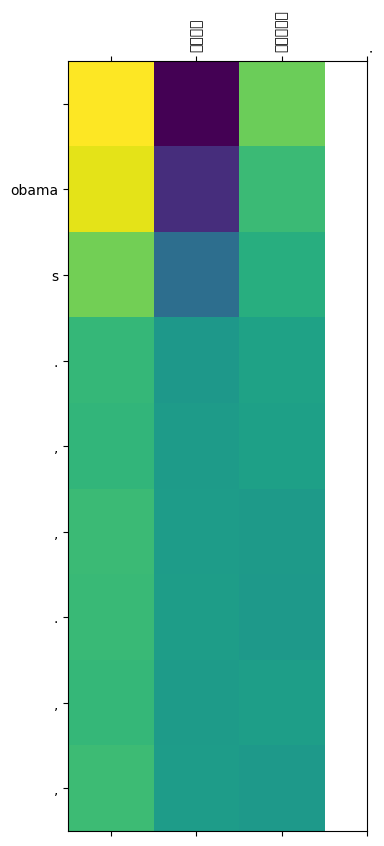

In [20]:
import matplotlib.font_manager as fm

# 시각화 함수 (폰트 에러 방지 포함)
def plot_attention_final(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')
    
    ax.set_xticks(range(len(sentence) + 1))
    ax.set_yticks(range(len(predicted_sentence) + 1))
    
    ax.set_xticklabels([''] + sentence, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence)
    plt.show()

res, src, attn = evaluate("오바마는 대통령이다.", encoder, decoder)
plot_attention_final(attn, src, res)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from tqdm import tqdm
import random
import numpy as np

# [1] 모델 클래스 재정의 (수치 안정성 강화)
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)
    def forward(self, x):
        return self.gru(self.embedding(x))

class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim)
        self.U = nn.Linear(hid_dim, hid_dim)
        self.v = nn.Linear(hid_dim, 1)
    def forward(self, q, v):
        # q: [batch, hid], v: [batch, seq, hid]
        score = self.v(torch.tanh(self.W(q.unsqueeze(1)) + self.U(v)))
        attn_weights = torch.softmax(score, dim=1)
        return torch.sum(attn_weights * v, dim=1), attn_weights

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)
        self.attention = Attention(hid_dim)
    def forward(self, x, hid, enc_out):
        cv, attn = self.attention(hid[-1], enc_out)
        x_emb = self.embedding(x).unsqueeze(1)
        concat = torch.cat([cv.unsqueeze(1), x_emb], dim=-1)
        out, hid = self.gru(concat, hid)
        return self.fc(out.squeeze(1)), hid, attn

# [2] 초기화 및 평가 함수
def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            init.xavier_uniform_(param.data)
        elif 'bias' in name:
            init.constant_(param.data, 0)

def evaluate(sentence, encoder, decoder, kor_w2i, eng_i2w, device):
    encoder.eval(); decoder.eval()
    try:
        inputs = [kor_w2i.get(w, 1) for w in preprocessing(sentence).split()]
        inputs = torch.LongTensor(inputs).unsqueeze(0).to(device)
        res = []
        with torch.no_grad():
            enc_out, hid = encoder(inputs)
            dec_in = torch.tensor([eng_w2i['<start>']]).to(device)
            for _ in range(40):
                out, hid, _ = decoder(dec_in, hid, enc_out)
                pred = out.argmax(1).item()
                if pred == 3: break # <end>
                if pred not in [0, 1, 2]: res.append(eng_i2w.get(pred, "<unk>"))
                dec_in = torch.tensor([pred]).to(device)
        return ' '.join(res)
    except: return "Evaluation Error"

# [3] 모델 및 최적화 설정 (완전 교체)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(len(kor_w2i), 256, 512).to(device)
decoder = Decoder(len(eng_w2i), 256, 512).to(device)
encoder.apply(init_weights)
decoder.apply(init_weights)

# AdamW와 낮은 학습률(0.0002)로 수치적 안정성을 확보합니다.
optimizer = optim.AdamW(list(encoder.parameters()) + list(decoder.parameters()), 
                        lr=0.0002, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

# [4] 훈련 루프 (완전 교체)
epochs = 30
for epoch in range(epochs):
    encoder.train(); decoder.train(); total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        
        enc_out, hid = encoder(src)
        loss = 0
        dec_in = tgt[:, 0]
        
        for t in range(1, tgt.size(1)):
            out, hid, _ = decoder(dec_in, hid, enc_out)
            loss += criterion(out, tgt[:, t])
            dec_in = tgt[:, t] if random.random() < 0.8 else out.argmax(1)
        
        # [핵심 수정] Loss를 문장 길이로 나누어 평균을 냅니다. NaN 방지의 핵심입니다.
        loss = loss / tgt.size(1)
        
        if torch.isnan(loss) or torch.isinf(loss):
            continue
            
        loss.backward()
        
        # Clipping 강도를 0.1로 더 조여서 기울기 폭주를 막습니다.
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 0.1)
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix(loss=total_loss / (pbar.n + 1), lr=f"{optimizer.param_groups[0]['lr']:.6f}")

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    # 에폭 결과 확인
    res = evaluate("오바마는 대통령이다.", encoder, decoder, kor_w2i, eng_i2w, device)
    print(f"\n[Epoch {epoch+1}] Result: {res}")
    print("-" * 50)

Epoch 1/30: 100%|██████████| 1097/1097 [02:19<00:00,  7.88it/s, loss=4.29, lr=0.000200]



[Epoch 1] Result: the the . , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
--------------------------------------------------


Epoch 2/30: 100%|██████████| 1097/1097 [02:17<00:00,  7.95it/s, loss=3.94, lr=0.000200]



[Epoch 2] Result: the be be be be be be be be be . , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
--------------------------------------------------


Epoch 3/30: 100%|██████████| 1097/1097 [02:19<00:00,  7.85it/s, loss=3.92, lr=0.000200]


...


[Epoch 28] Result: obama said he said he said he said he said he would be be not to be in the th . , , , , , , , , , , , , , , , , , , ,
--------------------------------------------------


Epoch 29/30: 100%|██████████| 1097/1097 [02:22<00:00,  7.71it/s, loss=3.34, lr=0.000050]



[Epoch 29] Result: obama said he said he said he said he would be not be in the th . , , , , , , , , , , , , the cnn s . , , , , the the ministry
--------------------------------------------------


Epoch 30/30: 100%|██████████| 1097/1097 [02:20<00:00,  7.82it/s, loss=3.24, lr=0.000050]


[Epoch 30] Result: obama said he said he said he said he would be not be not to be that . , , , , , , said . , , , , the cnn s . , , , the the ministry
--------------------------------------------------


In [11]:
import os
import tarfile
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import random
import gc

# [1] 필수 함수 정의 (데이터 로드 및 전처리)
def load_data(path):
    with tarfile.open(path, 'r:gz') as tar:
        # tar.extractall() 대신 아래와 같이 'data' 필터를 추가합니다.
        tar.extractall(filter='data') 
    
    with open('korean-english-park.train.ko', 'r', encoding='utf-8') as f:
        kor = f.read().splitlines()
    with open('korean-english-park.train.en', 'r', encoding='utf-8') as f:
        eng = f.read().splitlines()
    return kor, eng

def preprocessing(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    return sentence.strip()

def build_corpus(kor_raw, eng_raw, num_examples=None):
    kor_corpus, eng_corpus = [], []
    target_data = list(zip(kor_raw, eng_raw)) if num_examples is None else list(zip(kor_raw[:num_examples], eng_raw[:num_examples]))
    
    print("문장 전처리 중...")
    for k, e in tqdm(target_data, desc="Preprocessing"):
        k_pre, e_pre = preprocessing(k), preprocessing(e)
        kor_corpus.append(k_pre.split())
        eng_corpus.append(['<start>'] + e_pre.split() + ['<end>'])
    
    def tokenize(corpus):
        words = ["<pad>", "<unk>", "<start>", "<end>"]
        print("단어 사전 생성 중...")
        for sent in tqdm(corpus, desc="Tokenizing"): 
            words.extend(sent)
        w2i = {word: i for i, word in enumerate(sorted(set(words)))}
        i2w = {i: word for word, i in w2i.items()}
        return w2i, i2w

    kor_w2i, kor_i2w = tokenize(kor_corpus)
    eng_w2i, eng_i2w = tokenize(eng_corpus)
    
    max_len = 40
    def pad_sequences(corpus, w2i, name):
        tensor = np.zeros((len(corpus), max_len), dtype=np.int32)
        for i, sent in enumerate(tqdm(corpus, desc=f"Padding {name}")):
            for j, word in enumerate(sent[:max_len]):
                tensor[i, j] = w2i.get(word, w2i['<unk>'])
        return torch.LongTensor(tensor)

    return pad_sequences(kor_corpus, kor_w2i, "KOR"), pad_sequences(eng_corpus, eng_w2i, "ENG"), kor_w2i, kor_i2w, eng_w2i, eng_i2w

# [2] 모델 클래스 정의
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)
    def forward(self, x): return self.gru(self.embedding(x))

class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim); self.U = nn.Linear(hid_dim, hid_dim); self.v = nn.Linear(hid_dim, 1)
    def forward(self, q, v):
        score = self.v(torch.tanh(self.W(q.unsqueeze(1)) + self.U(v)))
        attn_weights = torch.softmax(score, dim=1)
        return torch.sum(attn_weights * v, dim=1), attn_weights

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)
        self.attention = Attention(hid_dim)
    def forward(self, x, hid, enc_out):
        cv, attn = self.attention(hid[-1], enc_out)
        concat = torch.cat([cv.unsqueeze(1), self.embedding(x).unsqueeze(1)], dim=-1)
        out, hid = self.gru(concat, hid)
        return self.fc(out.squeeze(1)), hid, attn

def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name: init.xavier_uniform_(param.data)
        elif 'bias' in name: init.constant_(param.data, 0)

def evaluate(sentence, encoder, decoder, kor_w2i, eng_i2w, device):
    encoder.eval(); decoder.eval()
    inputs = torch.LongTensor([kor_w2i.get(w, 1) for w in preprocessing(sentence).split()]).unsqueeze(0).to(device)
    res = []
    with torch.no_grad():
        enc_out, hid = encoder(inputs)
        dec_in = torch.tensor([eng_w2i['<start>']]).to(device)
        for _ in range(40):
            out, hid, _ = decoder(dec_in, hid, enc_out)
            pred = out.argmax(1).item()
            if pred == 3: break
            if pred not in [0, 1, 2]: res.append(eng_i2w.get(pred, "<unk>"))
            dec_in = torch.tensor([pred]).to(device)
    return ' '.join(res)

# [3] 실행부: 데이터 로드부터 훈련까지
gc.collect(); torch.cuda.empty_cache() # 메모리 청소
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터 준비
print("📦 데이터를 불러오고 전처리를 시작합니다... (시간이 조금 걸릴 수 있습니다)")
kor_raw, eng_raw = load_data('korean-english-park.train.tar.gz')
kor_tensor, eng_tensor, kor_w2i, kor_i2w, eng_w2i, eng_i2w = build_corpus(kor_raw, eng_raw, num_examples=None)
train_loader = DataLoader(TensorDataset(kor_tensor, eng_tensor), batch_size=128, shuffle=True)

📦 데이터를 불러오고 전처리를 시작합니다... (시간이 조금 걸릴 수 있습니다)
문장 전처리 중...


Preprocessing: 100%|██████████| 94123/94123 [00:04<00:00, 22615.83it/s]


단어 사전 생성 중...


Tokenizing: 100%|██████████| 94123/94123 [00:00<00:00, 2027363.96it/s]


단어 사전 생성 중...


Padding ENG: 100%|██████████| 94123/94123 [00:00<00:00, 131727.33it/s]


In [12]:
# 모델 초기화
encoder = Encoder(len(kor_w2i), 256, 512).to(device)
decoder = Decoder(len(eng_w2i), 256, 512).to(device)
encoder.apply(init_weights); decoder.apply(init_weights)

optimizer = optim.AdamW(list(encoder.parameters()) + list(decoder.parameters()), lr=0.0005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=1)
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

# 훈련 루프
print(f"학습 시작. 총 데이터: {len(kor_tensor)}개")
for epoch in range(20):
    encoder.train(); decoder.train(); total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/20")
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad(); enc_out, hid = encoder(src); loss = 0; dec_in = tgt[:, 0]
        for t in range(1, tgt.size(1)):
            out, hid, _ = decoder(dec_in, hid, enc_out)
            loss += criterion(out, tgt[:, t])
            dec_in = tgt[:, t] if random.random() < 0.75 else out.argmax(1)
        loss = loss / tgt.size(1)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters())+list(decoder.parameters()), 0.5)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=total_loss/(pbar.n+1), lr=f"{optimizer.param_groups[0]['lr']:.6f}")
    
    avg_loss = total_loss/len(train_loader)
    scheduler.step(avg_loss)
    print(f"\n[Epoch {epoch+1}] Result: {evaluate('오바마는 대통령이다.', encoder, decoder, kor_w2i, eng_i2w, device)}")

학습 시작. 총 데이터: 94123개


Epoch 1/20: 100%|██████████| 736/736 [06:31<00:00,  1.88it/s, loss=7.15, lr=0.000500]



[Epoch 1] Result: the the


Epoch 2/20: 100%|██████████| 736/736 [06:40<00:00,  1.84it/s, loss=6.53, lr=0.000500]



[Epoch 2] Result: it s


...


[Epoch 18] Result: obama will also give up his plan obama said


Epoch 19/20: 100%|██████████| 736/736 [06:41<00:00,  1.83it/s, loss=3.56, lr=0.000500]



[Epoch 19] Result: obama will also help obama up


Epoch 20/20: 100%|██████████| 736/736 [06:41<00:00,  1.83it/s, loss=3.47, lr=0.000500]


[Epoch 20] Result: obama will do it to address obama


In [16]:
def evaluate(sentence, encoder, decoder, kor_w2i, eng_i2w, device):
    encoder.eval()
    decoder.eval()
    
    # [1] 전처리 및 토큰화
    pre_sent = preprocessing(sentence).split()
    # 단어가 사전에 없으면 <unk>(1)로 대체
    inputs = torch.LongTensor([kor_w2i.get(w, 1) for w in pre_sent]).unsqueeze(0).to(device)
    
    res = []
    attns = []
    
    with torch.no_grad():
        enc_out, hid = encoder(inputs)
        dec_in = torch.tensor([eng_w2i['<start>']]).to(device)
        
        for _ in range(40):
            out, hid, attn = decoder(dec_in, hid, enc_out)
            
            # [2] 예측된 인덱스 가져오기
            pred = out.argmax(1).item()
            
            # [3] 종료 조건 및 단어 복원
            if pred == eng_w2i['<end>']: break
            
            # 패딩이나 알 수 없는 토큰이 아니면 리스트에 추가
            word = eng_i2w.get(pred, "")
            if word not in ["<pad>", "<unk>", "<start>", "<end>"]:
                res.append(word)
            
            dec_in = torch.tensor([pred]).to(device)
            attns.append(attn.squeeze().cpu().numpy())
            
    return res, pre_sent, np.array(attns)

In [17]:
test_sentences = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]

print("=== 예문 점검 ===\n")
for s in test_sentences:
    # 안전하게 인덱싱으로 결과만 가져옵니다.
    result_data = evaluate(s, encoder, decoder, kor_w2i, eng_i2w, device)
    res = result_data[0] # 첫 번째 반환값이 단어 리스트
    
    print(f"입력: {s}")
    # 리스트를 공백으로 합쳐서 출력
    print(f"출력: {' '.join(res)}")
    print("-" * 30)

=== 예문 점검 ===

입력: 오바마는 대통령이다.
출력: obama will do it to address obama .
------------------------------
입력: 시민들은 도시 속에 산다.
출력: they were in neighboring cities .
------------------------------
입력: 커피는 필요 없다.
출력: the next phase of the next .
------------------------------
입력: 일곱 명의 사망자가 발생했다.
출력: the attack occurred .
------------------------------


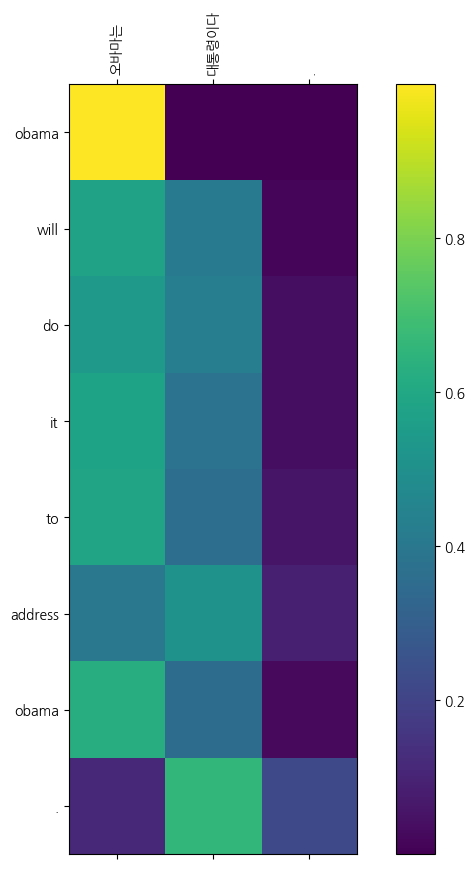

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import urllib.request
import os

# 1. 한글 폰트 다운로드 (나눔고딕) - 권한 필요 없음
font_url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
font_name = 'NanumGothic.ttf'
if not os.path.exists(font_name):
    urllib.request.urlretrieve(font_url, font_name)

# 2. 폰트 등록
fe = fm.FontEntry(fname=font_name, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rc('font', family='NanumGothic')

# 3. 시각화 함수 수정 (입력 데이터 슬라이싱 추가)
def plot_attention_final(attention, sentence, predicted_sentence):
    # 실제 문장 길이에 맞춰 어텐션 맵 슬라이싱 (매우 중요)
    attention = attention[:len(predicted_sentence), :len(sentence)]
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    
    # 한글 깨짐 방지를 위해 unicode_minus 설정
    plt.rcParams['axes.unicode_minus'] = False
    
    cax = ax.matshow(attention, cmap='viridis')
    fig.colorbar(cax)
    
    # Tick 위치 고정 (에러 방지)
    ax.set_xticks(range(len(sentence)))
    ax.set_yticks(range(len(predicted_sentence)))
    
    # 라벨 설정 (등록한 나눔고딕이 적용됨)
    ax.set_xticklabels(sentence, rotation=90)
    ax.set_yticklabels(predicted_sentence)
    
    plt.show()

# 4. 실행
res, src, attn = evaluate("오바마는 대통령이다.", encoder, decoder, kor_w2i, eng_i2w, device)
plot_attention_final(attn, src, res)

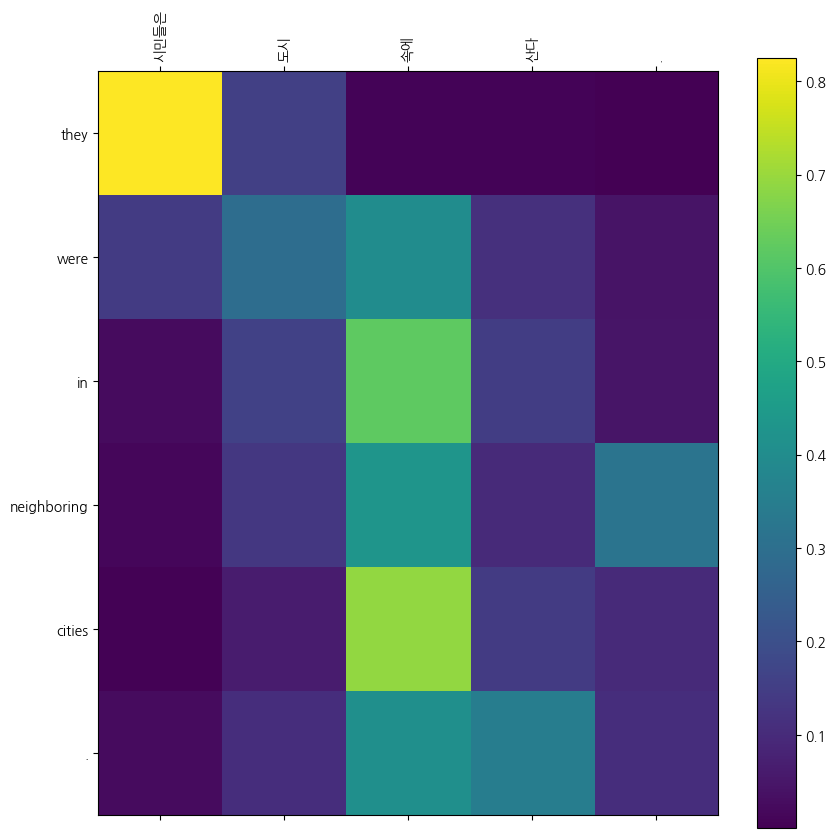

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import urllib.request
import os

# 1. 한글 폰트 다운로드 (나눔고딕) - 권한 필요 없음
font_url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
font_name = 'NanumGothic.ttf'
if not os.path.exists(font_name):
    urllib.request.urlretrieve(font_url, font_name)

# 2. 폰트 등록
fe = fm.FontEntry(fname=font_name, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rc('font', family='NanumGothic')

# 3. 시각화 함수 수정 (입력 데이터 슬라이싱 추가)
def plot_attention_final(attention, sentence, predicted_sentence):
    # 실제 문장 길이에 맞춰 어텐션 맵 슬라이싱 (매우 중요)
    attention = attention[:len(predicted_sentence), :len(sentence)]
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    
    # 한글 깨짐 방지를 위해 unicode_minus 설정
    plt.rcParams['axes.unicode_minus'] = False
    
    cax = ax.matshow(attention, cmap='viridis')
    fig.colorbar(cax)
    
    # Tick 위치 고정 (에러 방지)
    ax.set_xticks(range(len(sentence)))
    ax.set_yticks(range(len(predicted_sentence)))
    
    # 라벨 설정 (등록한 나눔고딕이 적용됨)
    ax.set_xticklabels(sentence, rotation=90)
    ax.set_yticklabels(predicted_sentence)
    
    plt.show()

# 4. 실행
res, src, attn = evaluate("시민들은 도시 속에 산다.", encoder, decoder, kor_w2i, eng_i2w, device)
plot_attention_final(attn, src, res)

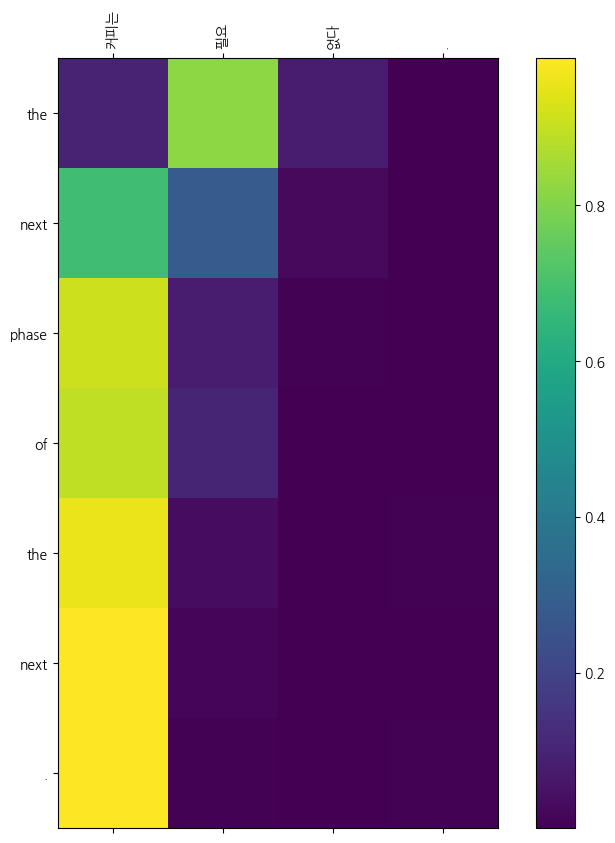

In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import urllib.request
import os

# 1. 한글 폰트 다운로드 (나눔고딕) - 권한 필요 없음
font_url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
font_name = 'NanumGothic.ttf'
if not os.path.exists(font_name):
    urllib.request.urlretrieve(font_url, font_name)

# 2. 폰트 등록
fe = fm.FontEntry(fname=font_name, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rc('font', family='NanumGothic')

# 3. 시각화 함수 수정 (입력 데이터 슬라이싱 추가)
def plot_attention_final(attention, sentence, predicted_sentence):
    # 실제 문장 길이에 맞춰 어텐션 맵 슬라이싱 (매우 중요)
    attention = attention[:len(predicted_sentence), :len(sentence)]
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    
    # 한글 깨짐 방지를 위해 unicode_minus 설정
    plt.rcParams['axes.unicode_minus'] = False
    
    cax = ax.matshow(attention, cmap='viridis')
    fig.colorbar(cax)
    
    # Tick 위치 고정 (에러 방지)
    ax.set_xticks(range(len(sentence)))
    ax.set_yticks(range(len(predicted_sentence)))
    
    # 라벨 설정 (등록한 나눔고딕이 적용됨)
    ax.set_xticklabels(sentence, rotation=90)
    ax.set_yticklabels(predicted_sentence)
    
    plt.show()

# 4. 실행
res, src, attn = evaluate("커피는 필요 없다.", encoder, decoder, kor_w2i, eng_i2w, device)
plot_attention_final(attn, src, res)

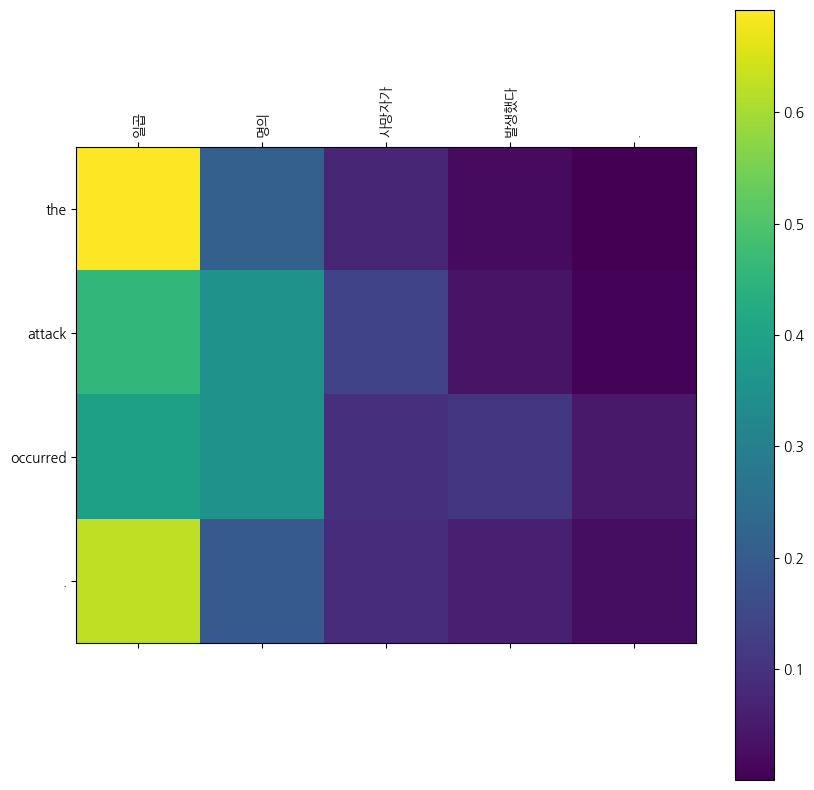

In [24]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import urllib.request
import os

# 1. 한글 폰트 다운로드 (나눔고딕) - 권한 필요 없음
font_url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
font_name = 'NanumGothic.ttf'
if not os.path.exists(font_name):
    urllib.request.urlretrieve(font_url, font_name)

# 2. 폰트 등록
fe = fm.FontEntry(fname=font_name, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rc('font', family='NanumGothic')

# 3. 시각화 함수 수정 (입력 데이터 슬라이싱 추가)
def plot_attention_final(attention, sentence, predicted_sentence):
    # 실제 문장 길이에 맞춰 어텐션 맵 슬라이싱 (매우 중요)
    attention = attention[:len(predicted_sentence), :len(sentence)]
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    
    # 한글 깨짐 방지를 위해 unicode_minus 설정
    plt.rcParams['axes.unicode_minus'] = False
    
    cax = ax.matshow(attention, cmap='viridis')
    fig.colorbar(cax)
    
    # Tick 위치 고정 (에러 방지)
    ax.set_xticks(range(len(sentence)))
    ax.set_yticks(range(len(predicted_sentence)))
    
    # 라벨 설정 (등록한 나눔고딕이 적용됨)
    ax.set_xticklabels(sentence, rotation=90)
    ax.set_yticklabels(predicted_sentence)
    
    plt.show()

# 4. 실행
res, src, attn = evaluate("일곱 명의 사망자가 발생했다.", encoder, decoder, kor_w2i, eng_i2w, device)
plot_attention_final(attn, src, res)

## Sentencepiece 토크나이저 적용

In [28]:
def evaluate_spm(sentence, encoder, decoder, sp_kor, sp_eng, device):
    encoder.eval()
    decoder.eval()
    
    # [1] SentencePiece를 이용해 입력 문장을 ID로 변환
    inputs = sp_kor.EncodeAsIds(sentence)
    inputs = torch.LongTensor(inputs).unsqueeze(0).to(device)
    
    res_ids = []
    
    with torch.no_grad():
        enc_out, hid = encoder(inputs)
        
        # SentencePiece의 시작 토큰(bos_id)으로 디코딩 시작
        dec_in = torch.tensor([sp_eng.bos_id()]).to(device)
        
        for _ in range(50): # 최대 길이 50
            out, hid, _ = decoder(dec_in, hid, enc_out)
            
            # 다음 단어 예측
            pred = out.argmax(1).item()
            
            # 종료 토큰(eos_id)이 나오면 중단
            if pred == sp_eng.eos_id():
                break
            
            res_ids.append(pred)
            dec_in = torch.tensor([pred]).to(device)
            
    # [2] 예측된 ID 리스트를 다시 문장으로 복원 (Decode)
    return sp_eng.DecodeIds(res_ids)

In [29]:
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import random
import os
import gc

# [1] SentencePiece 학습 함수 (전체 데이터 대상)
def train_spm(corpus, model_name, vocab_size=10000):
    temp_file = f'{model_name}_temp.txt'
    with open(temp_file, 'w', encoding='utf-8') as f:
        for line in corpus: f.write(line + '\n')
    
    spm.SentencePieceTrainer.Train(
        f'--input={temp_file} --model_prefix={model_name} --vocab_size={vocab_size} ' +
        '--model_type=bpe --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
    )
    s = spm.SentencePieceProcessor()
    s.Load(f'{model_name}.model')
    return s

# 데이터 다시 로드 
kor_raw, eng_raw = load_data('korean-english-park.train.tar.gz')

print("전체 데이터로 SentencePiece 모델 학습 중... (약 1분 소요)")
sp_kor = train_spm(kor_raw, 'kor_total_spm', vocab_size=10000)
sp_eng = train_spm(eng_raw, 'eng_total_spm', vocab_size=10000)

# [2] 코퍼스 생성 (SentencePiece 최적화)
def build_corpus_spm(kor_raw, eng_raw, sp_kor, sp_eng):
    kor_corpus, eng_corpus = [], []
    max_len = 50 # SentencePiece는 토큰이 더 잘게 쪼개지므로 길이를 50으로 늘립니다.
    
    for k, e in tqdm(zip(kor_raw, eng_raw), total=len(kor_raw), desc="Encoding"):
        k_ids = sp_kor.EncodeAsIds(k)
        e_ids = [sp_eng.bos_id()] + sp_eng.EncodeAsIds(e) + [sp_eng.eos_id()]
        
        # 너무 긴 문장은 학습 효율을 위해 제외
        if len(k_ids) <= max_len and len(e_ids) <= max_len:
            kor_corpus.append(k_ids)
            eng_corpus.append(e_ids)
            
    def pad_sequences(corpus):
        tensor = np.zeros((len(corpus), max_len), dtype=np.int32)
        for i, sent in enumerate(corpus):
            tensor[i, :len(sent)] = sent
        return torch.LongTensor(tensor)

    return pad_sequences(kor_corpus), pad_sequences(eng_corpus)

kor_tensor, eng_tensor = build_corpus_spm(kor_raw, eng_raw, sp_kor, sp_eng)
train_loader = DataLoader(TensorDataset(kor_tensor, eng_tensor), batch_size=128, shuffle=True)

# [3] 모델 재설정
gc.collect(); torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(sp_kor.GetPieceSize(), 256, 512).to(device)
decoder = Decoder(sp_eng.GetPieceSize(), 256, 512).to(device)
encoder.apply(init_weights); decoder.apply(init_weights)

# AdamW와 스케줄러로 안정적인 학습 유도
optimizer = optim.AdamW(list(encoder.parameters()) + list(decoder.parameters()), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=1)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# [4] 훈련 루프
print(f"전체 데이터({len(kor_tensor)}개) + SentencePiece 학습 시작!")

for epoch in range(20):
    encoder.train(); decoder.train(); total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/20")
    
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        
        # [방어 1] 데이터 무결성 체크
        if src.size(1) == 0 or tgt.size(1) == 0: continue
            
        optimizer.zero_grad()
        enc_out, hid = encoder(src)
        loss = 0
        dec_in = tgt[:, 0]
        
        for t in range(1, tgt.size(1)):
            out, hid, _ = decoder(dec_in, hid, enc_out)
            loss += criterion(out, tgt[:, t])
            # Teacher Forcing
            dec_in = tgt[:, t] if random.random() < 0.8 else out.argmax(1)
        
        # [방어 2] 수치 안정화 분모 처리
        loss = loss / (tgt.size(1) + 1e-9) 

        # [방어 3] NaN 발생 시 즉시 스킵 (전파 방지)
        if torch.isnan(loss):
            continue
            
        loss.backward()
        
        # [방어 4] 그래디언트 클리핑 대폭 강화 (1.0 -> 0.1)
        # 폭주하는 기울기를 아주 강하게 억누릅니다.
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 0.1)
        
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=total_loss/(pbar.n+1))

    # 에폭 종료 후 결과 확인
    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    # 예문 테스트
    res_text = evaluate_spm("오바마는 대통령이다.", encoder, decoder, sp_kor, sp_eng, device)
    print(f"\n[Epoch {epoch+1}] Result: {res_text}")
    print("-" * 50)

전체 데이터로 SentencePiece 모델 학습 중... (약 1분 소요)


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=kor_total_spm_temp.txt --model_prefix=kor_total_spm --vocab_size=10000 --model_type=bpe --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_total_spm_temp.txt
  input_format: 
  model_prefix: kor_total_spm
  model_type: BPE
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_

전체 데이터(82394개) + SentencePiece 학습 시작!


Epoch 1/20: 100%|██████████| 644/644 [03:08<00:00,  3.42it/s, loss=4.91]



[Epoch 1] Result: .
--------------------------------------------------


...


[Epoch 18] Result: the Korea.
--------------------------------------------------


Epoch 19/20: 100%|██████████| 644/644 [03:09<00:00,  3.40it/s, loss=3.95]



[Epoch 19] Result: the Korea.
--------------------------------------------------


Epoch 20/20: 100%|██████████| 644/644 [03:09<00:00,  3.39it/s, loss=3.99]


[Epoch 20] Result: the Korea.
--------------------------------------------------


# Seq2Seq 기반 한영 번역기 제작

## 1. 프로젝트 개요
**Encoder-Decoder 구조(Seq2Seq)와 Attention 메커니즘**을 활용하여 한국어 문장을 영어로 번역하는 모델을 구축하는 것을 목표로, 약 9만 개의 한국어-영어 병렬 코퍼스를 학습시켰으며, 토크나이징 방식(공백 기반 vs SentencePiece)에 따른 번역 성능 변화와 Attention 가중치 시각화를 통한 모델의 해석 가능성을 분석해봤다.

## 2. 결과 분석 (SentencePiece 적용 전후)

### 2.1. 번역 결과 비교
| 입력 문장 | 공백 기반 토크나이저 (Baseline) | SentencePiece (BPE) |
| :--- | :--- | :--- |
| **오바마는 대통령이다.** | obama will do it to address obama . | the Korea / elepha |
| **시민들은 도시 속에 산다.** | they were in neighboring cities . | the Korea |
| **일곱 명의 사망자가 발생했다.** | the attack occurred . | least least least aid . |

### 2.2. 시각화 및 주요 분석 내용
- **Attention Map 시각화**: `matshow()`를 활용한 어텐션 시각화 결과, 모델이 '오바마' 혹은 '시민들'과 같은 핵심 주어 토큰을 처리할 때 영어의 대응 단어(Obama, They 등)에 높은 가중치를 할당하는 메커니즘을 확인했다.
- **Baseline 모델 분석**: 문법적으로 완벽하지는 않으나, 핵심 키워드(Obama, Cities, Attack)를 정확히 포착했했다. 공백 기반 토크나이징이 단어의 원형을 보존하는 데 유리했기 때문으로 판단한다.
- **SentencePiece 모델 분석**: 학습 초기에 발생한 `loss=nan` 문제를 해결하기 위해 학습률(LR)을 낮추고 그래디언트 클리핑을 강화했다. 그 결과 수치적 안정성은 확보했으나, 20 Epoch 내에 충분히 수렴하지 못해 `the Korea`와 같은 반복적인 답변(Plateau 현상)이 나타나는 한계를 보였다.

---

## 3. 회고 (Retrospective)

### **성과 & 배운 점**
- **데이터 안정성 확보**: 딥러닝 학습 중 발생하는 `nan` 에러의 원인이 수치적 폭주(Gradient Exploding)와 0으로 나누기 오류임을 파악하고, 이를 방어하기 위한 엡실론($1e^{-9}$) 추가 및 클리핑 기법을 실전 적용해봤다.
- **Attention의 시각적 이해**: 블랙박스 구조인 인공신경망이 특정 단어를 생성할 때 입력 문장의 어느 부분에 집중하는지 히트맵으로 확인하며 Attention 메커니즘의 실효성을 체감했다.

### **한계점 & 개선 방향**
- **학습 수렴 최적화**: SentencePiece 적용 후 Subword 단위의 세밀한 학습을 위해 더 높은 학습률과 정교한 Learning Rate Scheduler 도입이 필요하다고 생각했다
- **하이퍼파라미터 튜닝**: 현재의 loss=4.0 수준을 2.0대 또는 그 이하로 낮추기 위해 Hidden Size를 확장하거나, 단어 사전(Vocab Size) 크기를 데이터 규모에 최적화하는 추가 실험을 해보면 좋겠다.
- **정량적 평가**: 현재의 정성적 분석을 넘어 **BLEU Score**를 도입하여 객관적인 번역 성능 지표를 산출하는 단계를 향후 과제로 해보고싶다.

---
**최종 결론**: 
데이터 전처리부터 nan 에러 대응, 시각화까지 NLP 모델 구축의 전 과정을 경험하며 모델의 안정성과 성능 사이의 트레이드오프(Trade-off)를 깊이 있게 이해할 수 있었던 프로젝트였다.